License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


# Nitrous Oxide Plant Example (content warning: #explosion, #death)


## Background

The following is an excerpt from The Morning News, Wilmington, DE on August 3, 1977. "Investigators sift through the debris from a blast in the quest to find the cause that destroyed the new nitrous oxide plant. A company spokesperson said it appears more likely that the blast was caused by another chemical -- ammonium nitrate -- used to produce nitrous oxide."

Read the full article [here](https://www.newspapers.com/article/the-morning-news-mark-h-frasier-air-pr/33173271/?locale=en-US) (content warning: #explosion, #death)

## Problem statement

A solution that is 83 wt% NH$_4$NO$_3$ and 17 wt% H$_2$O is fed at 200$^\mathrm{o}$F to a CSTR. Molten NH$_4$NO$_3$ decomposes directly to N$_2$O (g) and H$_2$O (g) inside the CSTR. It is believed that pressure fluctuations were observed inside the reactor, so an operator turned off the feed.

Let's denote NH$_4$NO$_3$ as "A" and H$_2$O as "w".

## Additional data

- The conversion inside the CSTR was thought to be 0.9999 under steady state
operation.
- It is believed that there were 500 lbm A inside the CSTR at steady state
- It is believed that the temperature of the CSTR was 510$^\mathrm{o}$F at steady state
- $\Delta H^{rxn}$ = -336 BtU/lbm A at 500$^\mathrm{o}$F and this value can be assumed to be constant
- $C_{PA}$ = 0.38 BtU/lbm A*$^\mathrm{o}$F = 30.4 BtU/lbmol A*$^\mathrm{o}$F
- $C_{Pw}$ = 0.47 BtU/lbm w*$^\mathrm{o}$F = 8.5 BtU/lbmol w*$^\mathrm{o}$F
- Molar weight of A = 80
- Molar weight of w = 18
- $-r_A = kM_A$ where $M_A$ is the mass in lbm of A inside the CSTR
- $k$ = 0.00517 min$^{-1}$ at 510$^\mathrm{o}$F
- $\frac{E^{act}}{R}$ = 44520$^\mathrm{o}$R
- $\Delta H^{vap}_w$ = 1034 BtU/lbm w

## Questions

### Analyze the CSTR

1. Draw and label the system under normal operation.
2. Derive the mass balance for the CSTR.
3. Use the mass balance to determine the mass of NH4NO3 in the reactor under steady state operation.
4. Derive the energy balance for the CSTR.
5. Using the information above, write an expression for .
6. Use the energy balance to determine the amount of energy that is added to or removed from the system (via heat and shaft work) under normal operation.
7. Analyze the reactor after the feed is shut off
8. When the feed is shut off, let's assume that the heating system and flow out of the reactor are also shut off. Will the reaction still progress?

### Adiabatic batch reactor

9. Draw and label the system.
10. Derive the mass balance for this system.
11. Write down the energy balance for this system.
12. Use the mass and energy balance under adiabatic batch reactor operation to determine how many minutes pass until the reactor explodes.

### Analyze the safety decisions

13. Why did turning off the feed and the heating system cause the temperature to increase?
14. List some alternative strategies to turning off the feed for circumstances when the reactor is not running properly.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

## Problem Data

In [ ]:
Hrxn=-336 # Btu/lbm A
CPA = 0.38 # given in problem statement
CPw_l = 1.0 # Btu/lbm*F. The problem statement gives a different value; let's use this one which is well known.
MWA=80 # lbm/lbmol A
MWw=18 # lbm/lbmol w
k0=0.00517*60 # hr^-1 at 510F
Eterm=44520 # Rankine
Hvapw=1034 # Btu/lbm w
print("CPA = ",CPA," Btu/lbm*F")

CPA =  0.38  Btu/lbm*F


## Reaction

Let's denote N$_2$O as B:

A (l) $\longrightarrow$ B (g) + w (g)

## CSTR solution

- $x_{A0}$ = 0.83 (mass fraction)
- $x_{w0}$ = 0.17 (mass fraction)
- feed flowrate (total) = 310 lbm/hr
- feed temperature, $T_0$ = 200F
- feed is liquid
- hypothetical conversion = 0.9999
- hypothetical amount of mass inside the reactor, $M_A$ = 500 lbm
- hypothetical reactor T = 510F
- reactor contents are gases

In [ ]:
xA0=0.83
xw0=0.17
mdottot0=310 # lbm/hr
T0=200 # F
X_hypothetical=0.9999
MA_hypothetical=500 # lbm
T_hypothetical = 510 # F
mdotA0=mdottot0*xA0
mdotw0=mdottot0*xw0

### Arrhenius equation

In [ ]:
def k(T):
  return k0*np.exp(Eterm*(1/(510+460)-1/(T+460)))

### Mass of A inside the reactor

In [ ]:
def mdotA(X):
  return mdottot0*xA0*(1-X)

### Rate law

In [ ]:
def rate(M,T):
  return -k(T)*M

### Mole balance

In [ ]:
def cstr_mb(M,X,T):
  return mdotA0 - mdotA(X) + rate(M,T)

### Energy balance

In [ ]:
R_gas = 1.987 # Btu/lbmol*R
CP_IG = 4*R_gas # Btu/lbmol*R
CPw_g = CP_IG/MWw # Btu/lbm*R
def cstr_eb(Ws,X,T):
  dHw = CPw_l*(T0-212) + (-Hvapw) + CPw_g*(212-T)
  return mdotA0*CPA*(T0-T) + mdotw0*dHw + mdotA0*X*(-Hrxn) + Ws

### Determine MA

In [ ]:
MA_guess = MA_hypothetical
MA_solved = fsolve(cstr_mb, x0=MA_guess, args=(X_hypothetical,T_hypothetical))[0]
print("MA needed for steady state operation using hypothetical values of X and T = ",MA_solved," lbm.")

MA needed for steady state operation using hypothetical values of X and T =  829.3819148936169  lbm.


### Determine Ws

In [ ]:
Ws_guess = 5000
Ws_solved = fsolve(cstr_eb, x0=Ws_guess, args=(X_hypothetical, T_hypothetical))[0]
print("Ws needed for steady state operation using hypothetical values of X and T = ",Ws_solved," Btu/hr = ",Ws_solved/2545," hp.")

Ws needed for steady state operation using hypothetical values of X and T =  5924.438657777762  Btu/hr =  2.3278737358655253  hp.


It would not be unreasonable that the stirrer was contributing up to 2.0 hp to the system. The remaining energy maybe coming from a heating jacket. (Hence, it maybe more accurately a $\dot{Q} + \dot{W}_s$ term).

### Model sensitivity to hypothetical values

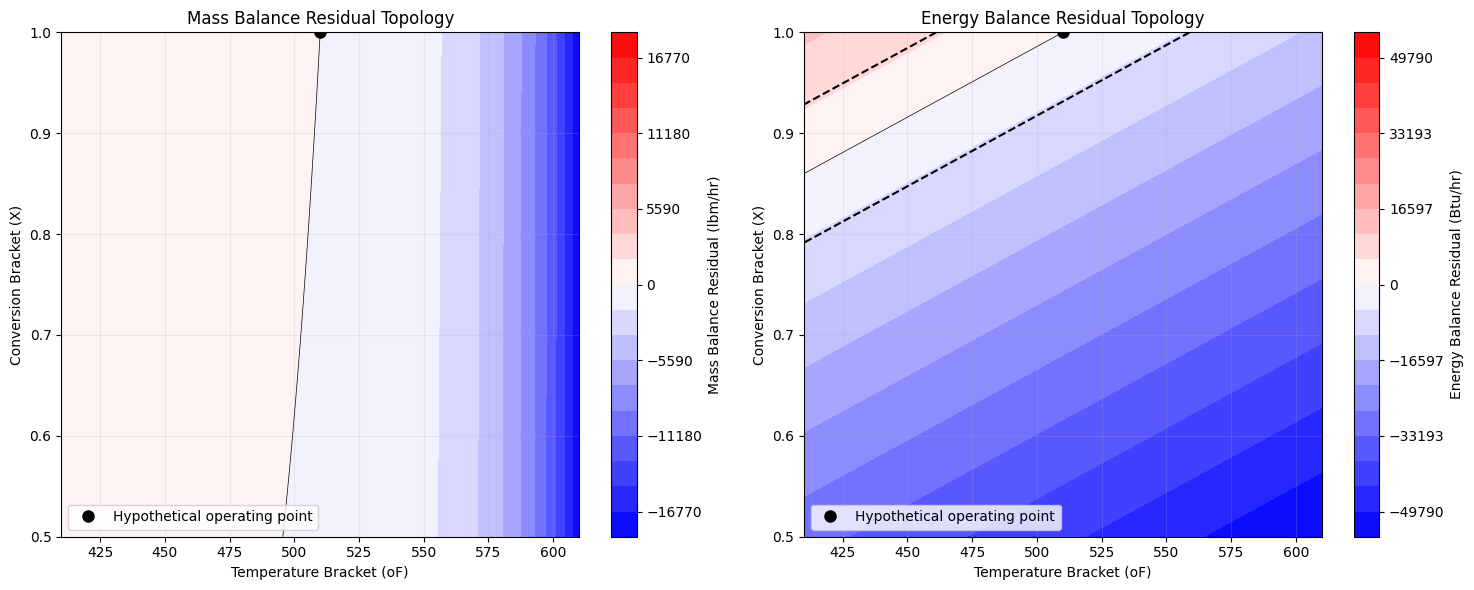

In [ ]:
# Bracket CSTR operating temperature and conversion around the hypothetical values
T_bracket = np.linspace(410, 610, 200)
X_bracket = np.linspace(0.50, 1.0, 200)
X_mesh, T_mesh = np.meshgrid(X_bracket, T_bracket)

# Evaluate the mole and energy balances
mass_residual = cstr_mb(MA_solved, X_mesh, T_mesh)
energy_residual = cstr_eb(Ws_solved, X_mesh, T_mesh)

# Plot the results
# going to use a contour plot and want to align the color bars
max_mass_val = max(abs(mass_residual.min()), abs(mass_residual.max()))
max_energy_val = max(abs(energy_residual.min()), abs(energy_residual.max()))

# Using an odd number of divisions puts a "point" on zero
mass_levels = np.linspace(-max_mass_val, max_mass_val, 21)
energy_levels = np.linspace(-max_energy_val, max_energy_val, 21)

# plot 2 plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Passing vmin, vmax, and symmetric levels forces the middle color to be exactly 0
cf1 = ax1.contourf(T_mesh, X_mesh, mass_residual, levels=mass_levels, cmap='bwr', vmin=-max_mass_val, vmax=max_mass_val)
fig.colorbar(cf1, ax=ax1, label='Mass Balance Residual (lbm/hr)')

# Add a line at 0
ax1.contour(T_mesh, X_mesh, mass_residual, levels=[0], colors='black', linewidths=0.5)

#plot the hypothetical operating point
ax1.plot(510, 0.9999, 'ko', markersize=8, label='Hypothetical operating point')

ax1.set_title('Mass Balance Residual Topology')
ax1.set_xlabel('Temperature Bracket (oF)')
ax1.set_ylabel('Conversion Bracket (X)')
ax1.grid(True, alpha=0.2)
ax1.legend(loc='lower left')

cf2 = ax2.contourf(T_mesh, X_mesh, energy_residual, levels=energy_levels, cmap='bwr', vmin=-max_energy_val, vmax=max_energy_val)
fig.colorbar(cf2, ax=ax2, label='Energy Balance Residual (Btu/hr)')
ax2.contour(T_mesh, X_mesh, energy_residual, levels=[0], colors='black', linewidths=0.5)
ax2.contour(T_mesh, X_mesh, energy_residual, levels=[-Ws_solved,Ws_solved], colors='black', linewidths=1.5, linestyles='dashed')
#plot the hypothetical operating point
ax2.plot(510, 0.9999, 'ko', markersize=8, label='Hypothetical operating point')
ax2.set_title('Energy Balance Residual Topology')
ax2.set_xlabel('Temperature Bracket (oF)')
ax2.set_ylabel('Conversion Bracket (X)')
ax2.grid(True, alpha=0.2)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()


The mass balances isn't very sensitive to X or T. The energy balance is more sensitive to both X and T. We can see from the energy balance plot that 510$^\mathrm{o}$F is the maximum temperature that would allow steady state operation. So it's possible that the CSTR temperature is a little lower than 510$^\mathrm{o}$F. The dashed line in the energy balance plot is the same magnitude as the $\dot{Q} + \dot{W}_s$ term.

## Adiabatic batch reactor solution

When the feed is shut off, we have several hundred lbm of A in the reactor. There is also w and B in the reactor. We can assume that w and B are both gases due to the hot temperature.

### Energy balance

We need $\Delta C_P$ and $\sum_i \Theta_i C_{Pi}$.

To get $\Delta C_P$:

In [ ]:
MWB = 44
CPB = CP_IG/MWB
dCP_lbmol = 2*CPw_g*MWw + CPB*MWB - CPA*MWA
dCP = dCP_lbmol*1/MWA
print("Delta CP = ",dCP_lbmol," Btu/lbmol A * F = ",dCP," Btu/lbm A * F")

Delta CP =  -6.555999999999997  Btu/lbmol A * F =  -0.08194999999999997  Btu/lbm A * F


To get $\sum_i \Theta_i C_{Pi}$, we need to know how much w and B are in the reactor when the feed gets shut off. In a typical CSTR, we would assume that the fluid composition inside the reactor = the fluid composition coming out of the reactor. The composition coming out of the reactor can be calculated from the conversion:

In [ ]:
X_cstr = X_hypothetical
mdotA_solved = mdotA(X_cstr)
theta_w_cstr = xw0/xA0
mdotw = mdottot0*xA0*(theta_w_cstr+2*X_cstr*(MWw/MWA))
mdotB = mdottot0*xA0*X_cstr*(MWB/MWA)
print("mdotA = ",mdotA_solved," lbm/hr")
print("mdotw = ",mdotw," lbm/hr")
print("mdotB = ",mdotB," lbm/hr")
print("mdottot = ",mdotA_solved+mdotw+mdotB," lbm/hr")

mdotA =  0.02572999999999717  lbm/hr
mdotw =  168.4734215  lbm/hr
mdotB =  141.50084850000002  lbm/hr
mdottot =  310.0  lbm/hr


Values of $\Theta$ are hence:

In [ ]:
theta_w = mdotw/mdotA_solved
theta_B = mdotB/mdotA_solved
print("theta_w = ",theta_w,"lbm w/lbm A")
print("theta_B = ",theta_B,"lbm B/lbm A")

theta_w =  6547.742771085058 lbm w/lbm A
theta_B =  5499.4500000006055 lbm B/lbm A


Hence, $\sum_i \Theta_i C_{Pi}$ =

In [ ]:
ThiCpi = CPA + CPw_g*theta_w + CPB*theta_B
print("ThiCpi = ",ThiCpi," Btu/lbm A * F")

ThiCpi =  3884.972846921445  Btu/lbm A * F


We can now write the energy balance. We have two options here. One is the adiabatic energy balance:

In [ ]:
def T_adiabatic(X,T0):
  return T0 + ((-Hrxn)*X)/(ThiCpi + X*dCP)

The other is to account for the $\dot{Q} + \dot{W}_s$ term. If we do that, we have to couple the energy balance with the mass balance:

### Mass balance

In [ ]:
T0_batch = T_hypothetical
def batch_mb(t,y):
  X=y
  MA=MA0_batch*(1-X)
  T = T_adiabatic(X,T0_batch)
  rA = rate(MA,T)
  return -rate(MA,T)/MA0_batch

### Coupled ODEs

In [ ]:
MA0_batch = MA_solved
def batch_reactor_odes(t,y):
  X,T=y
  MA=MA0_batch*(1-X)
  rA = rate(MA,T)
  dXdt = -rate(MA,T)/MA0_batch
  dTdt = (rA*Hrxn+Ws_solved)/(MA0_batch*(ThiCpi+dCP*X))
  return [dXdt,dTdt]

## Solve the IVPs

In [ ]:
tmin=0
tmax_minutes=1000 # minutes
tmax=tmax_minutes/60 # hours
t_eval=np.linspace(tmin,tmax,400)
X0_batch = 0
initial_conditions=[X0_batch,T0_batch]
sol_ad=solve_ivp(batch_mb,[tmin,tmax],[initial_conditions[0]],t_eval=t_eval,method='Radau')
sol_coupled=solve_ivp(batch_reactor_odes,[tmin,tmax],initial_conditions,t_eval=t_eval,method='Radau')
t_ad=sol_ad.t
X_ad=sol_ad.y[0]
T_ad=np.array([T_adiabatic(x,T0_batch) for x in X_ad])
t_coupled=sol_coupled.t
X_coupled=sol_coupled.y[0]
T_coupled=sol_coupled.y[1]

## Plot the results

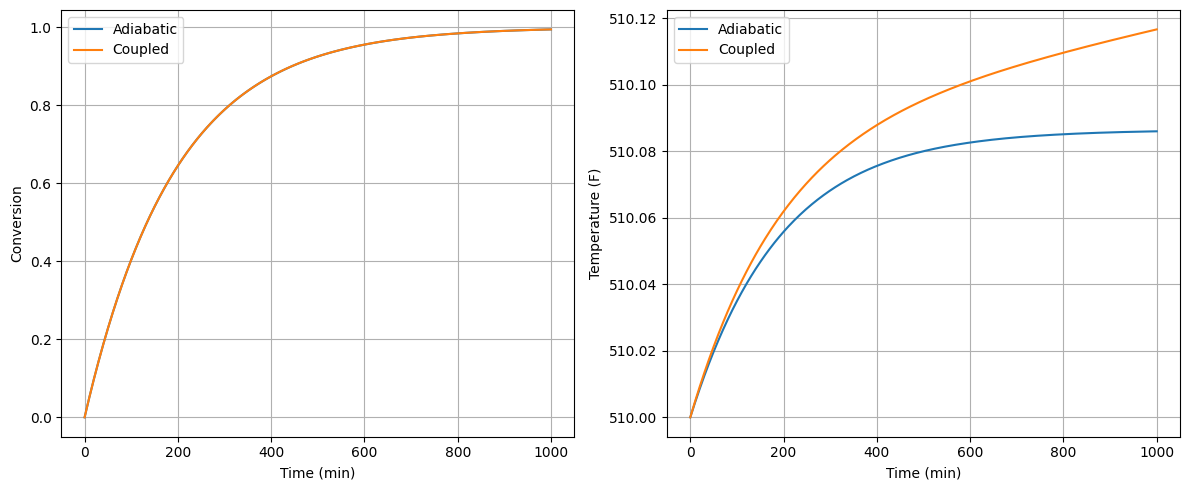

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_ad * 60, X_ad, label="Adiabatic")
ax1.plot(t_coupled * 60, X_coupled, label="Coupled")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Conversion")
ax1.grid(True)
ax1.legend()

ax2.plot(t_ad * 60, T_ad, label="Adiabatic")
ax2.plot(t_coupled * 60, T_coupled, label="Coupled")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Temperature (F)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Using these assumptions, the reactor operates very safely, taking ~17 hours to fully convert, and the temperature is essentially constant.

However, there is a flaw in our modeling decisions. This reactor comprises multiple phases. The feed to the CSTR is a liquid, which reacts with nearly 100% conversion. The product is gas. Under the "well-mixed" assumption, the reactants react immediately upon entering the reactor. This means that the liquid volatilizes immediately. We can imagine that the liquid is agitated by this alone (similar to when a liquid is boiling). The stirrer agitates the liquid even further. In fact, its job is to help release the gas from the liquid.

The gas and liquid streams are likely drawn off the reactor separately (gas from the top, liquid from the bottom). The *liquid* is hence likely nearly pure NH$_4$NO$_3$.

The liquid is also our system. If we assume that the liquid is pure A then $\Theta_w = \Theta_B = 0$.

Further, $\Delta C_P = 0$. This is probably a bit puzzling, since A indeed is reacting to form w and B. However, we have made the assumption that our system is pure A. As A reacts, the amount of A indeed decreases. However, the reaction doesn't influence the ability of A to store heat.

By assuming that the system is pure A, we are assuming that w and B leave the system as soon as they are formed. Hence, their heat capacities become irrelevant in the energy balance.

Therefore:

In [ ]:
ThiCpi = CPA
dCP = 0
print("ThiCpi = ",ThiCpi," Btu/lbm A * F")
print("dCP = ",dCP," Btu/lbm A * F")

ThiCpi =  0.38  Btu/lbm A * F
dCP =  0  Btu/lbm A * F


In [ ]:
tmin=0
tmax_minutes=12 # minutes
tmax=tmax_minutes/60 # hours
t_eval=np.linspace(tmin,tmax,400)
X0_batch = 0
initial_conditions=[X0_batch,T0_batch]
sol_ad=solve_ivp(batch_mb,[tmin,tmax],[initial_conditions[0]],t_eval=t_eval,method='Radau')
sol_coupled=solve_ivp(batch_reactor_odes,[tmin,tmax],initial_conditions,t_eval=t_eval,method='Radau')
t_ad=sol_ad.t
X_ad=sol_ad.y[0]
T_ad=np.array([T_adiabatic(x,T0_batch) for x in X_ad])
t_coupled=sol_coupled.t
X_coupled=sol_coupled.y[0]
T_coupled=sol_coupled.y[1]

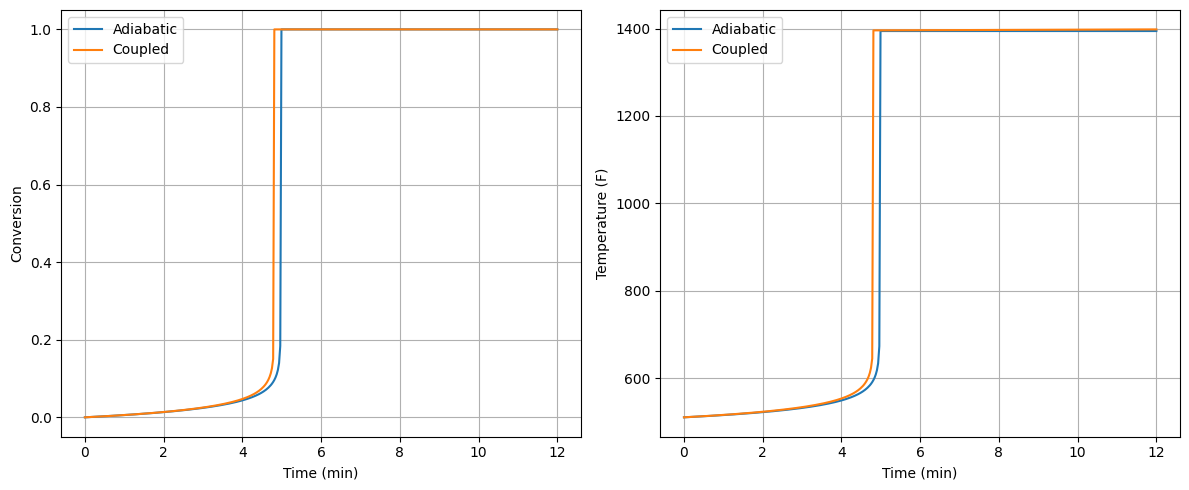

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_ad * 60, X_ad, label="Adiabatic")
ax1.plot(t_coupled * 60, X_coupled, label="Coupled")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Conversion")
ax1.grid(True)
ax1.legend()

ax2.plot(t_ad * 60, T_ad, label="Adiabatic")
ax2.plot(t_coupled * 60, T_coupled, label="Coupled")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Temperature (F)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

With less heat capacity in the system, the temperature rises quickly, given the highly exothermic value of $\Delta H^{rxn}$. The temperature spike is evident in this graph; the explosion occurs after only a few minutes of batch operation.

### The importance of heat capacity

We've seen here 2-3 examples of the importance of heat capacity in this system.

- In the case where we assumed the entire reactor was well mixed, the reaction proceeded safely to completion.
- In the case where we considered the multiphase nature of the reactor, which limited the system to the liquid only, there was not enough heat capacity to absorb the heat of reaction, which led to failure.

Now, let's address the 🐘 in the room. *The heat capacities given in the problem are wrong.* Specifically, $C_{PA}$ is actually more than *double* the value given in the problem statement.

Let's run the simulation again, this time using the real value of $C_{PA}$:




## Using the real value of $C_{PA}$

In [ ]:
CPA_SI = 3300 # J/kg*K
CPA = CPA_SI*(1/1.8)*(0.454/1)*(1/1055.06)

ThiCpi = CPA
dCP = 0
print("ThiCpi = ",ThiCpi," Btu/lbm A * F")
print("dCP = ",dCP," Btu/lbm A * F")

ThiCpi =  0.7888966820212439  Btu/lbm A * F
dCP =  0  Btu/lbm A * F


Reference for CPA = [Chemical Engineering Journal Advances, 2025](https://doi.org/10.1016/j.ceja.2025.100914)

We have to re-calculate $\dot{W}_s$:

In [ ]:
Ws_guess = 5000
Ws_solved = fsolve(cstr_eb, x0=Ws_guess, args=(X_hypothetical, T_hypothetical))[0]
print("Ws needed for steady state operation using hypothetical values of X and T = ",Ws_solved," Btu/hr = ",Ws_solved/2545," hp.")

Ws needed for steady state operation using hypothetical values of X and T =  38539.26470583824  Btu/hr =  15.1431295504276  hp.


And then re-solve the design equations:

In [ ]:
tmin=0
tmax_minutes=12 # minutes
tmax=tmax_minutes/60 # hours
t_eval=np.linspace(tmin,tmax,400)
X0_batch = 0
initial_conditions=[X0_batch,T0_batch]
sol_ad=solve_ivp(batch_mb,[tmin,tmax],[initial_conditions[0]],t_eval=t_eval,method='Radau')
sol_coupled=solve_ivp(batch_reactor_odes,[tmin,tmax],initial_conditions,t_eval=t_eval,method='Radau')
t_ad=sol_ad.t
X_ad=sol_ad.y[0]
T_ad=np.array([T_adiabatic(x,T0_batch) for x in X_ad])
t_coupled=sol_coupled.t
X_coupled=sol_coupled.y[0]
T_coupled=sol_coupled.y[1]

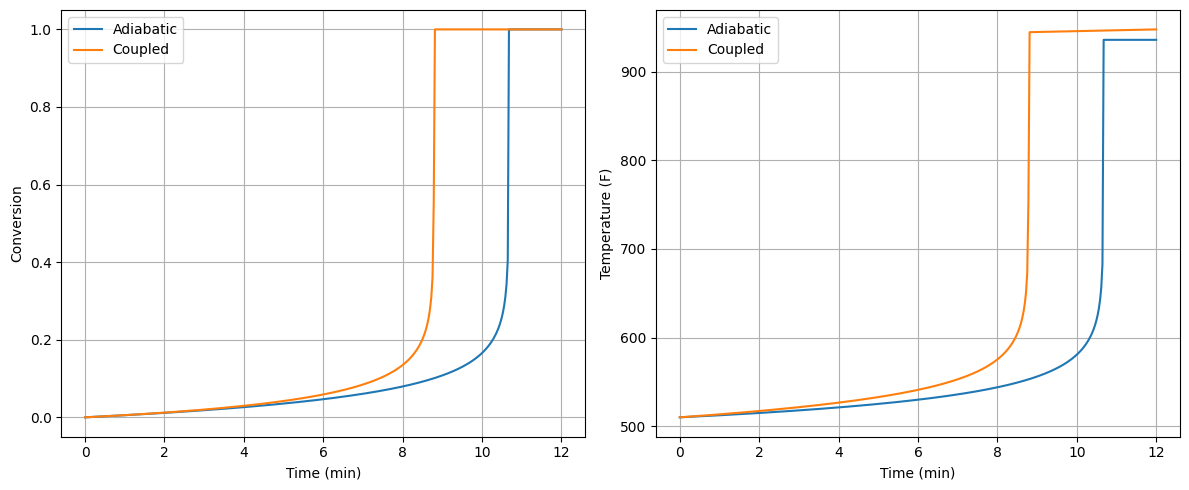

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_ad * 60, X_ad, label="Adiabatic")
ax1.plot(t_coupled * 60, X_coupled, label="Coupled")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Conversion")
ax1.grid(True)
ax1.legend()

ax2.plot(t_ad * 60, T_ad, label="Adiabatic")
ax2.plot(t_coupled * 60, T_coupled, label="Coupled")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Temperature (F)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Now we see the explosion occurring a little bit later, around 8.5 minutes. Why is this?

### Analysis

The performance of the batch reactor is quite sensitive to heat capacity. When the problem was written (see the [original problem statement](https://learning.oreilly.com/library/view/elements-of-chemical/9780133887822/ch13.xhtml#ch13prob02B)), the heat capacities were artificially adjusted to make the final result match what the news article was saying. (Writing engineering problems is a large effort in balancing the use of realistic values with problems that can be reasonably solved.)

When we use the real value of $C_{PA}$, we get results that differ from reality. Why is this?

The reason is because *side reactions start occuring*. For example, in addition to N$_2$O and H$_2$O, side reactions to form NH$_3$ (g) and HNO$_3$ (g) can also occur (see [citation](https://doi.org/10.1016/j.jhazmat.2008.10.054)). HNO$_3$ specifically can donate a proton, which acts as an acid catalyst, and can further accelerate the reaction. *We have not taken such phenomena into account in our model*; hence, we cannot replicate what happened in reality (unless we artificially adjust parameter values).

Another thing we can do is to model the extent to which other processes influenced the rate during the temperature spike. We can do this by adjusting the rate expression:

In [ ]:
def rate_adjusted(M,T,alpha):
  return -k(T)*M*alpha

In [ ]:
alpha = 2 # guess this value until you get the desired result
MA0_batch = MA_solved
def batch_reactor_odes(t,y):
  X,T=y
  MA=MA0_batch*(1-X)
  rA = rate_adjusted(MA,T,alpha)
  dXdt = -rA/MA0_batch
  dTdt = (rA*Hrxn+Ws_solved)/(MA0_batch*(ThiCpi+dCP*X))
  return [dXdt,dTdt]

In [ ]:
tmin=0
tmax_minutes=12 # minutes
tmax=tmax_minutes/60 # hours
t_eval=np.linspace(tmin,tmax,400)
X0_batch = 0
initial_conditions=[X0_batch,T0_batch]
sol_coupled=solve_ivp(batch_reactor_odes,[tmin,tmax],initial_conditions,t_eval=t_eval,method='Radau')
t_coupled=sol_coupled.t
X_coupled=sol_coupled.y[0]
T_coupled=sol_coupled.y[1]

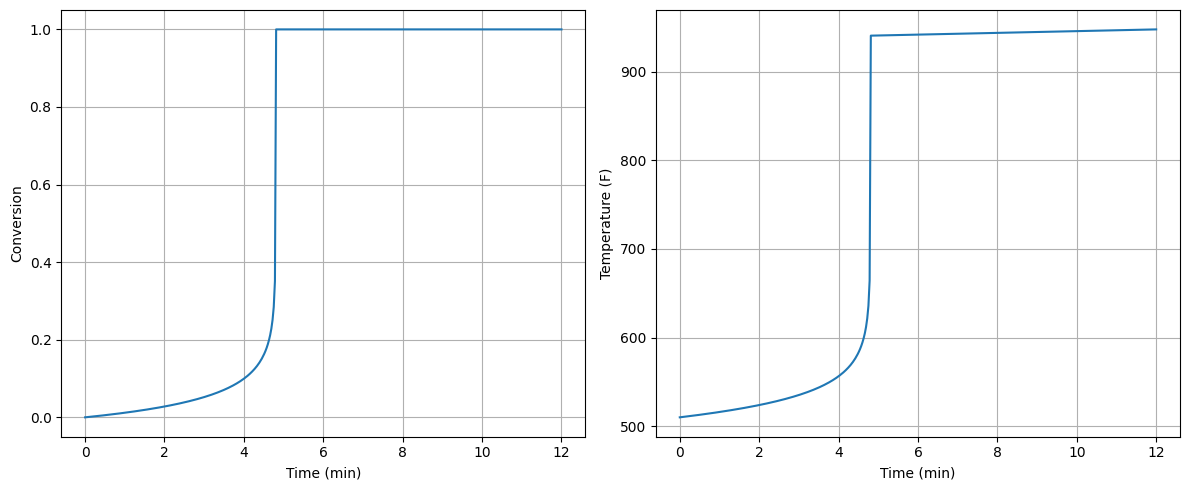

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_coupled * 60, X_coupled, label="Coupled")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Conversion")
ax1.grid(True)

ax2.plot(t_coupled * 60, T_coupled, label="Coupled")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Temperature (F)")
ax2.grid(True)

plt.tight_layout()
plt.show()

A value of $\alpha = 2$ replicates what happened in reality. What this suggests is that the existence of side reactions essentially doubled the rate of reaction.